Connected successfully


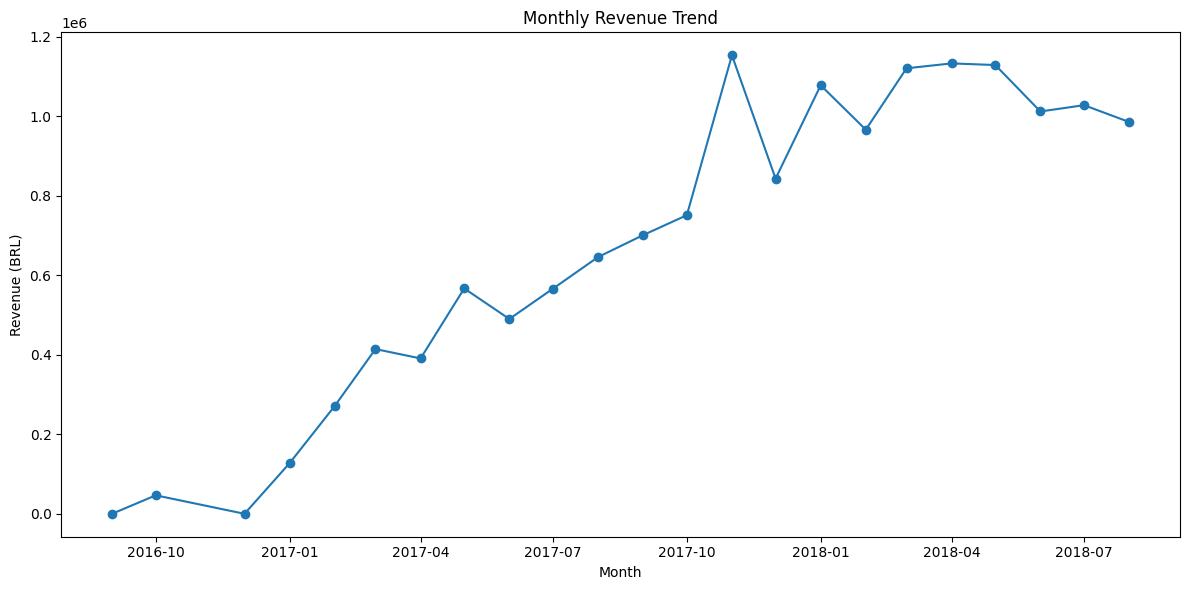

<Figure size 640x480 with 0 Axes>

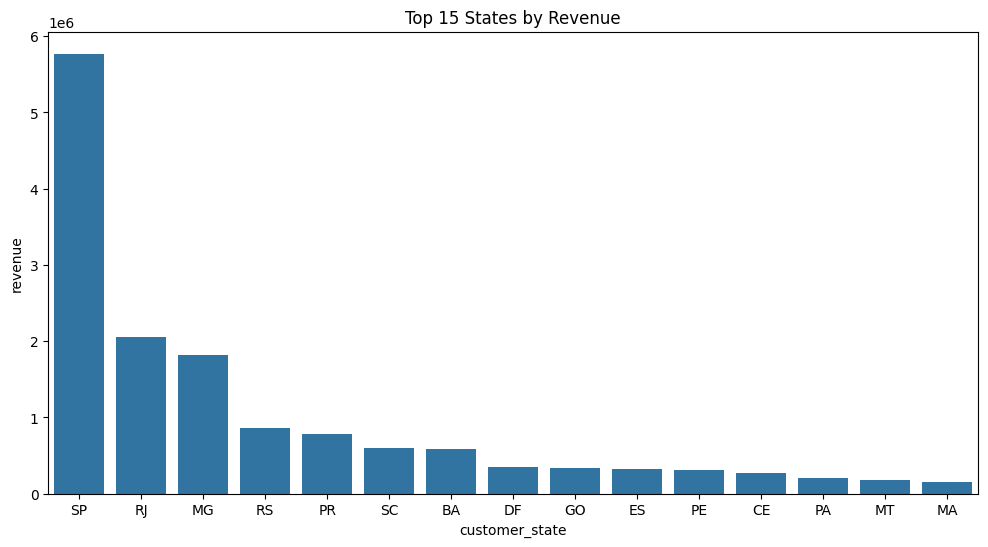

<Figure size 640x480 with 0 Axes>

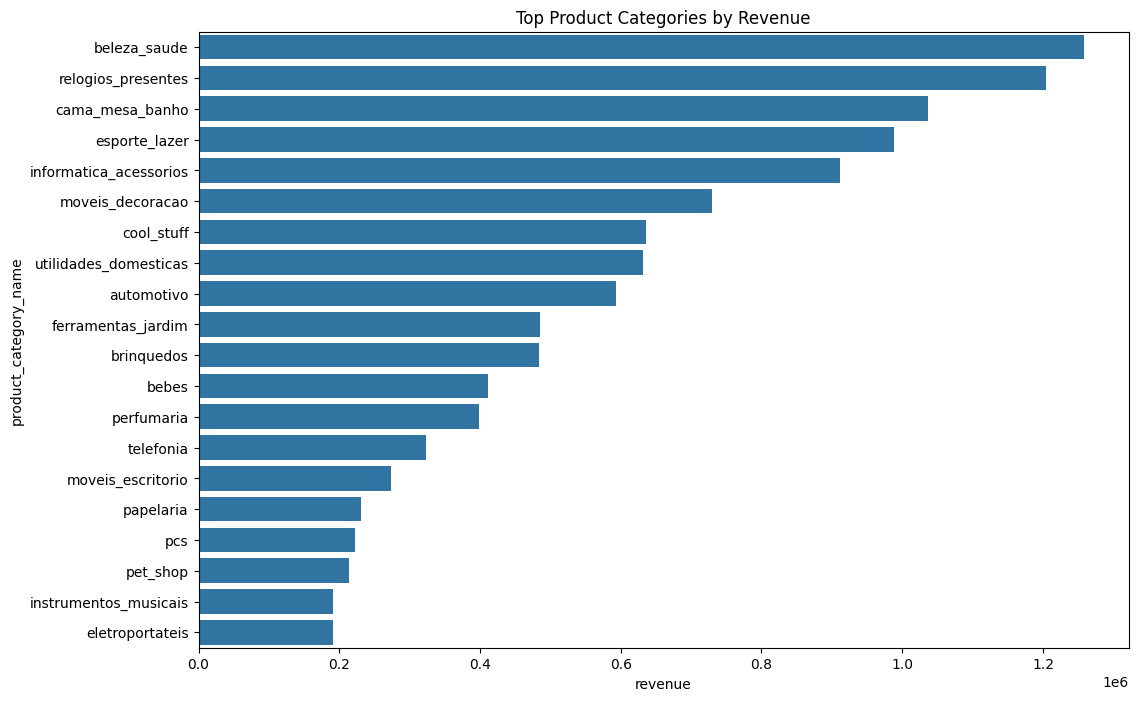

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from dotenv import load_dotenv

import os

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://"
    f"{os.getenv('DB_USER')}:"
    f"{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:"
    f"{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}"
)

print("Connected successfully")




#create charts
import os

os.makedirs(
    "../outputs/figures",
    exist_ok=True
)





#first chart, EDA Q1: How is revenue changing over time?
query = """
SELECT
DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
SUM(oi.price + oi.freight_value) AS revenue
FROM orders o
JOIN order_items oi
ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY 1
ORDER BY 1;
"""
df_rev = pd.read_sql(       #load
    query,
    engine
)

df_rev.head()

plt.figure(figsize=(12,6))       #revenue trend chart

plt.plot(
    df_rev["month"],
    df_rev["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")

plt.tight_layout()

plt.show()


plt.savefig(                                    #save figure
    "../outputs/figures/01_monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

#second chart, EDA Q2: which states generate the most revenue?
query = """
SELECT
c.customer_state,
SUM(oi.price + oi.freight_value) AS revenue
FROM customers c
JOIN orders o
ON c.customer_id = o.customer_id
JOIN order_items oi
ON o.order_id = oi.order_id
WHERE o.order_status='delivered'
GROUP BY c.customer_state
ORDER BY revenue DESC;
"""

df_state = pd.read_sql(             #create chart
    query,
    engine
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_state.head(15),
    x="customer_state",
    y="revenue"
)

plt.title("Top 15 States by Revenue")

plt.show()


plt.savefig(                             #save figures
    "../outputs/figures/02_top_states_revenue.png",
    dpi=300,
    bbox_inches="tight"
)


#Third chart, EDA Q3: which product category makes the most money?
query = """
SELECT
COALESCE(
t.product_category_name_english,
p.product_category_name
) AS category,
SUM(oi.price) AS revenue
FROM order_items oi
JOIN products p
ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY revenue DESC
LIMIT 20;
"""
df_cat = pd.read_sql(                   #make chart
    query,
    engine
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=df_cat,
    y="product_category_name",
    x="revenue"
)

plt.title("Top Product Categories by Revenue")

plt.show()

plt.savefig(                            #save figure
    "../outputs/figures/03_top_categories.png",
    dpi=300,
    bbox_inches="tight"
)

# outputs/
# └── figures/
#     ├── 01_monthly_revenue.png
#     ├── 02_top_states_revenue.png
#     └── 03_top_categories.png